# Using PyVRP on MAEnvs4VRP instances

### Install MAEnvs4VRP and PyVRP

Uncomment the following cells:

In [1]:
#!pip install pyvrp

In [2]:
#!git clone https://github.com/MAEnvs4VRP/maenvs4vrp.git

In [3]:
# When using Colab
#%cd maenvs4vrp
#!pip install .[notebooks]
#%cd maenvs4vrp/learning_notebooks

This notebook demonstrates the process of obtaining CVRPTW solutions from the [PyVRP](https://pyvrp.org/), an open-source, state-of-the-art vehicle routing problem solver, when applied to instances generated using **MAEnvs4VRP** tools.

In [4]:
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform

In [5]:
from pyvrp import Model
from pyvrp.stop import MaxRuntime

In [6]:
from maenvs4vrp.environments.cvrptw.instances_generator import InstanceGenerator
from maenvs4vrp.environments.cvrptw.benchmark_instances_generator import BenchmarkInstanceGenerator
from maenvs4vrp.environments.cvrptw.env import Environment
from maenvs4vrp.environments.cvrptw.observations import Observations
from maenvs4vrp.environments.cvrptw.env_agent_selector import AgentSelector
from maenvs4vrp.environments.cvrptw.env_agent_reward import DenseReward

### Benchmark Instances

Let's start with a classic Solomon instance:

In [7]:
BenchmarkInstanceGenerator.get_list_of_instances().keys()

maenvs4vrp/environments/cvrptw/benchmark_instances_generator.py:58: RuntimeWarning: Benchmark instance sets ['Homberger'] are not available locally. Instantiate BenchmarkInstanceGenerator to download them from HuggingFace ('maenvs4vrp/environments').
  warnings.warn(


dict_keys(['Solomon', 'Homberger'])

In [8]:
all_inst = BenchmarkInstanceGenerator.get_list_of_instances()['Solomon']

In [9]:
generator = BenchmarkInstanceGenerator(instance_name='Solomon', list_of_instances=all_inst)

In [10]:
instance_name='RC101'

In [11]:
instance = generator.get_instance(instance_name)

In [12]:
instance

{'name': 'RC101',
 'num_agents': 25,
 'num_nodes': 101,
 'data': TensorDict(
     fields={
         capacity: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
         coords: Tensor(shape=torch.Size([1, 101, 2]), device=cpu, dtype=torch.float32, is_shared=False),
         demands: Tensor(shape=torch.Size([1, 101]), device=cpu, dtype=torch.float32, is_shared=False),
         depot_idx: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
         end_time: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32, is_shared=False),
         is_depot: Tensor(shape=torch.Size([1, 101]), device=cpu, dtype=torch.bool, is_shared=False),
         service_time: Tensor(shape=torch.Size([1, 101]), device=cpu, dtype=torch.float32, is_shared=False),
         speed: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
         start_time: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.float32,

Now that we've obtained the dictionary containing the instance information, we'll convert it into the format required by **PyVRP**.

In [13]:
def create_data_model(instance, num_agents=25, n_digits=10, scale = 10):
    """Stores the data for the problem.
    
    Args:
        instance: Dictionary containing problem instance data
        num_agents: Number of vehicles/agents to use (default: 25)
        n_digits: Number of digits to round distances to (default: 10)
        scale: Scaling factor for distance/time values (default: 10)
        
    Returns:
        Dictionary containing formatted data for the routing problem
    """
    data = {}
    # Extract coordinates from instance and convert to numpy array
    coords = instance['coords'].numpy()
    # Calculate pairwise distances between all coordinates
    dist = squareform(pdist(coords))
    if n_digits:
        # Round distances to specified precision if n_digits is provided
        dist = np.floor(n_digits * squareform(pdist(coords)))/n_digits
    
    # Store coordinates as regular Python list
    data['coords'] = instance['coords'].tolist()
    # Scale and convert distance matrix to integers
    data['dist_matrix'] = (scale * dist).astype(int).tolist()
    # Use same values for time matrix (assuming distance = time)
    data['time_matrix'] = (scale * dist).astype(int).tolist()
    # Scale and format time windows as tuples of (earliest, latest) arrival times
    data['time_windows'] = [(int(scale * tw[0]), int(scale * tw[1])) for tw in zip(instance['tw_low'].tolist(), instance['tw_high'].squeeze(0).tolist())]
    # Set number of vehicles available
    data['num_vehicles'] = num_agents
    # Convert demand values to integer list
    data['demands'] = instance['demands'].type(torch.int32).tolist()
    # Scale and convert service times to integer list
    data['service_times'] = (scale * instance['service_time']).type(torch.int32).tolist()
    # Set vehicle capacity
    data['capacity'] = int(instance['capacity'])
    # Set depot location index
    data['depot'] = int(instance['depot_idx'].item())
    # Calculate maximum tour duration based on start and end times
    start_time = int(scale * instance['start_time'].item())
    end_time = int(scale * instance['end_time'].item())
    max_tour_duration = end_time - start_time
    data['max_tour_duration'] = max_tour_duration
    return data

In [14]:
scale = 1_000

In [15]:
data = create_data_model(instance['data'][0], scale=scale)

In [16]:
data['num_vehicles']

25

In [17]:
def solver(data):
    m = Model()

    depot = m.add_depot(
    x=data['coords'][0][0],
    y=data['coords'][0][1])

    m.add_vehicle_type(
        num_available=data['num_vehicles'],
        start_depot=depot,
        end_depot=depot,
        tw_early=data['time_windows'][0][0],
        tw_late=data['time_windows'][0][1],
        capacity=data['capacity'])
    
    clients = [
        m.add_client(
            x=data['coords'][idx][0],
            y=data['coords'][idx][1],
            delivery= data['demands'][idx] ,
            service_duration= data['service_times'][idx] ,
            tw_early=data['time_windows'][idx][0],
            tw_late=data['time_windows'][idx][1],
        )
        for idx in range(1, len(data['coords']))
            ]

    locations = [depot, *clients]
    for frm_idx, frm in enumerate(locations):
        for to_idx, to in enumerate(locations):
            distance = data['dist_matrix'][frm_idx][to_idx]
            duration = data['time_matrix'][frm_idx][to_idx]
            m.add_edge(frm, to, distance=distance, duration=duration)
    
    res = m.solve(stop=MaxRuntime(10)) 
    return res, m

In [18]:
res, m = solver(data)
print(res)

PyVRP v0.13.4


Solving an instance with:


    1 depot


    100 clients


    25 vehicles (1 vehicle type)


...

    distance: 1626100


    duration: 2788400


# iterations: 11822


    run-time: 10.00 seconds


Solution results
    # routes: 16
     # trips: 16
   # clients: 100
   objective: 1626100
    distance: 1626100
    duration: 2788400
# iterations: 11822
    run-time: 10.00 seconds

Routes
------
Route #1: 82 11 15 16 9 10 13 17
Route #2: 63 33 28 30 34 50 91
Route #3: 5 45 2 7 6 8 3 1 70
Route #4: 92 31 29 27 26 32 93
Route #5: 72 39 36 40 38 41 54 96
Route #6: 69 98 88 53 78 60
Route #7: 95 62 67 71 94 80
Route #8: 83 19 76 89 48
Route #9: 65 52 99 57 86 74
Route #10: 61 81 68 55
Route #11: 42 44 43 37 35
Route #12: 59 75 87 97 58 77
Route #13: 64 51 85 84 56 66
Route #14: 23 21 18 49 22 20 25 24
Route #15: 90
Route #16: 14 47 12 73 79 46 4 100



Let's examine the resulting solution.

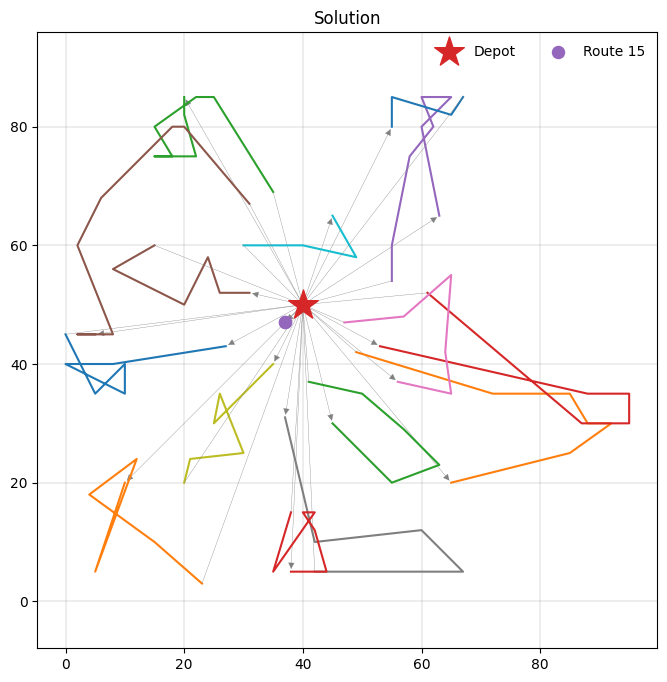

In [19]:
from pyvrp.plotting import plot_solution

_, ax = plt.subplots(figsize=(8, 8))
plot_solution(res.best, m.data(), ax=ax)

Next, let's verify the solution's validity within the MAEnvs4VRP environment.

In [20]:
gen = BenchmarkInstanceGenerator(instance_name='Solomon', list_of_instances=all_inst)
obs = Observations()
sel = AgentSelector()
rew = DenseReward()
env = Environment(instance_generator_object=gen,  
                obs_builder_object=obs,
                agent_selector_object=sel,
                reward_evaluator=rew,
                seed=0)

In [21]:
td = env.reset_agent_select_observe(num_agents=len(res.best.routes()), instance_name=instance_name, sample_type='not_random')
rewards = []
for idx, route in enumerate(res.best.routes(), 1):
    actions = route.visits() + [0]
    for action in actions:
        td['next_action'] = torch.tensor([[action]])
        td = env.step_agent_select_observe(td)
        rewards.append( td['reward'] + td['penalty'])

env.check_solution_validity()

print('distance: ', -torch.stack(rewards).sum(dim = 0).squeeze(-1).item())

distance:  1626.0999755859375


In [22]:
print(f'env best time:, {-torch.stack(rewards).sum(dim = 0).squeeze(-1).item():.2f}')
print(f'solver best time:, {res.best.distance()/scale:.2f}, n agents: {len(res.best.routes())}')

env best time:, 1626.10
solver best time:, 1626.10, n agents: 16


As expected, we get the same value in both cases.

## Baseline values using PyVRP

Let's now use PyVRP to obtain baseline reference values for our validation instances, which are crucial for evaluating new neuro-solver algorithms.

In [23]:
val_set = 'val_servs_100_agents_20'  # pre-generated validation set, downloaded on demand from Hugging Face

In [24]:
generator = InstanceGenerator(instance_name=val_set)
generator.load_list_of_instances()

In [25]:
obs = Observations()
sel = AgentSelector()
rew = DenseReward()
env = Environment(instance_generator_object=generator,  
                obs_builder_object=obs,
                agent_selector_object=sel,
                reward_evaluator=rew,
                seed=0)

In [26]:
total_times = []
total_nv = []
scale = 1_000
instance_name = generator.list_of_instances[0]
print(instance_name)
    
inst_dict = generator.get_instance(instance_name)
n_digits = inst_dict.get('n_digits')
num_agents = inst_dict['num_agents']
batch_size = inst_dict['data'].batch_size[0]
n_eval = 4  # number of instances to solve (10s each); use batch_size for the full set
for k in range(min(n_eval, batch_size)):
    instance = create_data_model(inst_dict['data'][k], n_digits=n_digits, scale=scale)
    
    res, _ = solver(instance)
    
    total_times.append(res.best.distance()/scale)
    total_nv.append(len(res.best.routes()))

print(f'av. time:, {np.mean(total_times)}, av agents: {np.mean(total_nv)}')

cvrptw/data/generated/val_servs_100_agents_20/generated_val_servs_100_agents_20_0
PyVRP v0.13.4


Solving an instance with:


    1 depot


    100 clients


    25 vehicles (1 vehicle type)


...

    distance: 21436


    duration: 41670


# iterations: 9654


    run-time: 10.00 seconds


av. time:, 24.887999999999998, av agents: 16.75


## Acknowledgements: 

* [PyVRP](https://pyvrp.org/)